In [8]:
report_full = "../../output/zymo/ERR3152366.summary_identity_stats.csv"
report_isolates = "../../output/alignment_with_isolates/ERR3152366_vs_"

isolate_names = ["Listeria monocytogenes", 
                 "Pseudomonas aeruginosa",
                 "Bacillus subtilis",
                 "Saccharomyces cerevisiae",
                 "Escherichia coli",
                 "Salmonella enterica",
                 "Lactobacillus fermentum",
                 "Enterococcus faecalis",
                 "Cryptococcus neoformans",
                 "Staphylococcus aureus"]

isolate_genome_names = ["Listeria_monocytogenes_complete_genome", 
                 "Pseudomonas_aeruginosa_complete_genome",
                 "Bacillus_subtilis_complete_genome",
                 "Saccharomyces_cerevisiae_draft_genome",
                 "Escherichia_coli_complete_genome",
                 "Salmonella_enterica_complete_genome",
                 "Lactobacillus_fermentum_complete_genome",
                 "Enterococcus_faecalis_complete_genome",
                 "Cryptococcus_neoformans_draft_genome",
                 "Staphylococcus_aureus_complete_genome"]

theoretical_abundance = [0.891, 0.089, 0.0089, 0.0089, 0.00089, 0.00089, 0.000089, 0.0000089, 0.0000089, 0.00000089]

In [18]:
import pandas as pd

# Read the full report
full_report_df = pd.read_csv(report_full)
num_alignments_full = full_report_df["primary_alns"].item()
identity_full = full_report_df["identity"].item() * 100

In [5]:
num_alignments

3395063

In [20]:
identity_list = []
num_alignments_list = []


for i in range(len(isolate_names)):
    isolate_report_path = report_isolates + isolate_genome_names[i] + ".summary_identity_stats.csv"
    isolate_report_df = pd.read_csv(isolate_report_path)
    identity_isolate = isolate_report_df["identity"].item() * 100
    num_alignments_isolate = isolate_report_df["primary_alns"].item()

    identity_list.append(identity_isolate)
    num_alignments_list.append(num_alignments_isolate)
    

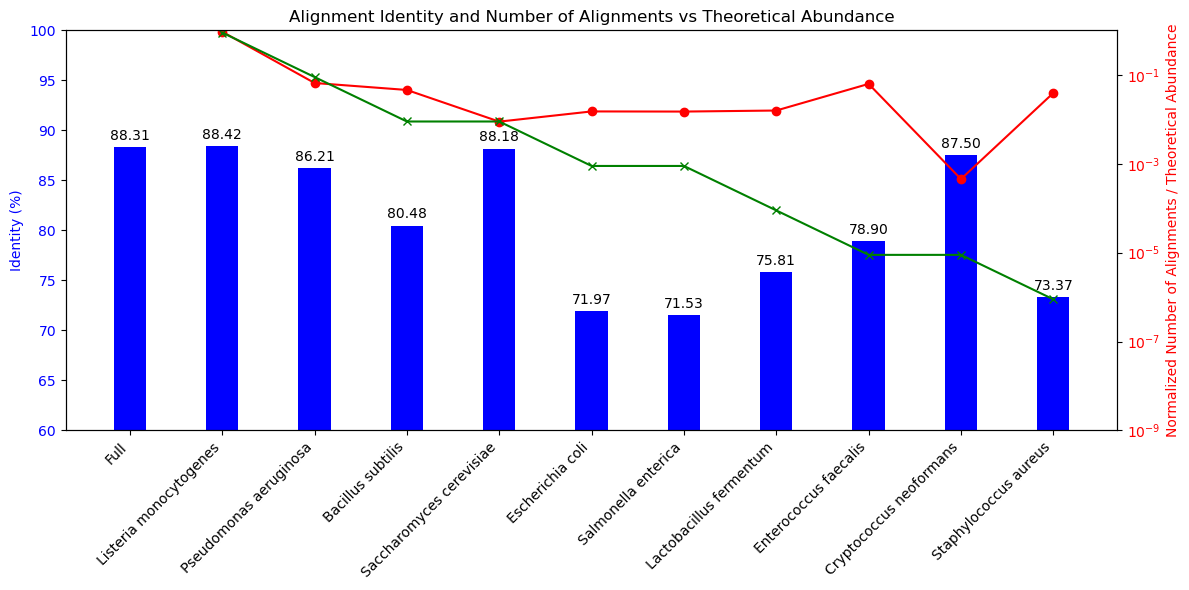

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the results: Bar plot of the identity for the full & each isolate, along with two line plots for the number of alignments (normalized by the total number of alignments) and theoretical abundance in log scale.

x = np.arange(len(isolate_names) + 1)  # the label locations
width = 0.35  # the width of the bars
fig, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.bar(x, [identity_full] + identity_list, width, label='Identity', color='b')
ax1.set_ylabel('Identity (%)', color='b')
ax1.set_xticks(x)
ax1.set_xticklabels(['Full'] + isolate_names, rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(60, 100)
ax1.bar_label(bars, fmt='%.2f', padding=3)
ax1.set_title('Alignment Identity and Number of Alignments vs Theoretical Abundance')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
num_alignments_normalized = [n / num_alignments_full for n in num_alignments_list]
line1, = ax2.plot(x[1:], num_alignments_normalized, color='r', marker='o', label='Normalized Number of Alignments')
line2, = ax2.plot(x[1:], theoretical_abundance, color='g', marker='x', label='Theoretical Abundance')
ax2.set_ylabel('Normalized Number of Alignments / Theoretical Abundance', color='r')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(1e-9, 1)
#fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9), bbox_transform=ax1.transAxes)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [ ]:
num